In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from TDECalculator import TDECalculator

plt.style.use("plot_style.mplstyle")
plt.rc('text', usetex=True)

In [22]:
def energy_plots(whole_star_sample): 
    # unpack
    dE_rand   = whole_star_sample['dEnergy_random']      # shape (nr-1, N_Omega)
    dE_unp    = whole_star_sample['dEnergy_unperturbed']
    dT_rand   = whole_star_sample['dT_random']
    dT_unp    = whole_star_sample['dT_unperturbed']
    dMass     = whole_star_sample['dMass']               # same shape

    # set up figure
    fig, (axE, axT) = plt.subplots(1, 2, figsize=(12,5))

    # histograms in E
    bins_E = np.linspace(-2, 2, 200)
    axE.hist(dE_rand.flatten(),
            weights=dMass.flatten(),
            bins=bins_E,
            density=True,
            alpha=0.5)
    axE.set_yscale('log')
    axE.set_xlim(-1,1)
    axE.set_ylim(1e-5,10)
    axE.set_xlabel(r'$ E / \Delta E$')
    axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')

    # histograms in T
    bins_T = np.logspace(0, 6, 200)
    axT.hist(dT_rand.flatten(),
            weights=dMass.flatten(),
            bins=bins_T,
            density=True,
            alpha=0.5)
    # overplot T^{-5/3} reference
    axT.plot(bins_T, 10*bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
    axT.set_xscale('log')
    axT.set_yscale('log')
    axT.set_xlim(1,2000)
    axT.set_ylim(2e-5,0.1)
    axT.set_xlabel(r'$T / \Delta T$')
    axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')

    plt.tight_layout()
    plt.show()

In [23]:
mass = 'MAMS5Msun'
Mbh = 1e6
Rp = 18
a = 0.5
n = 1000

In [24]:
calc = TDECalculator(mass, 'rel', Mbh, Rp, a, n)
calc_n = TDECalculator(mass, 'nwtn', Mbh, Rp, 0.0, n)
calc_s = TDECalculator(mass, 'rel', Mbh, Rp, 0.0, n)
calc2 = TDECalculator(mass, 'rel', Mbh, Rp, -a, n)

In [25]:
whole_star_sample1 = calc.rel_whole_star_sample(N_Omega=300**2)

In [26]:
whole_star_sample2 = calc2.rel_whole_star_sample(N_Omega=300**2)

In [27]:
whole_star_sample_s = calc_s.rel_whole_star_sample(N_Omega=300**2)

In [28]:
whole_star_sample_n = calc_n.whole_star_sample(N_Omega=300**2)

ordering: prograde, retrograde, schwartzschild, newtonian

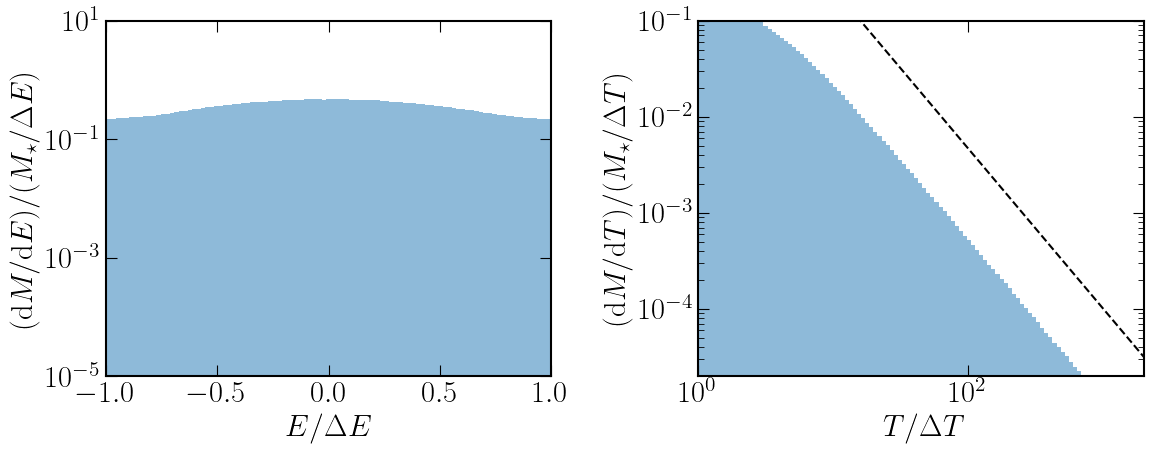

In [29]:
energy_plots(whole_star_sample1)

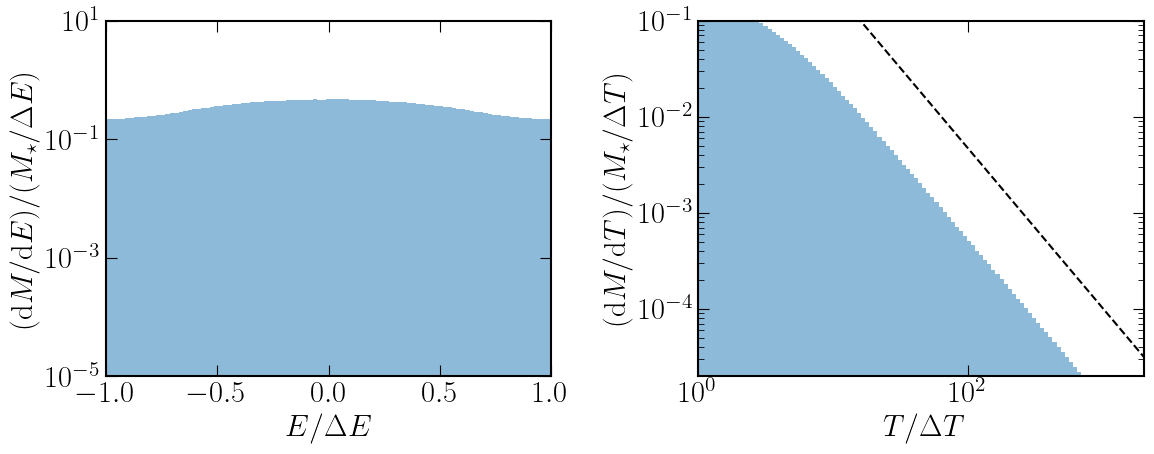

In [30]:
energy_plots(whole_star_sample2)

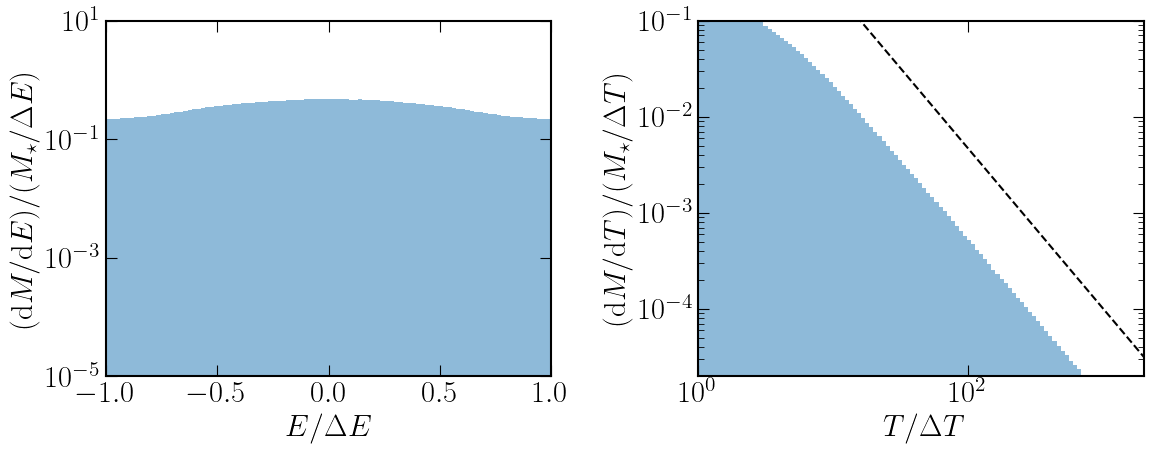

In [31]:
energy_plots(whole_star_sample_s)

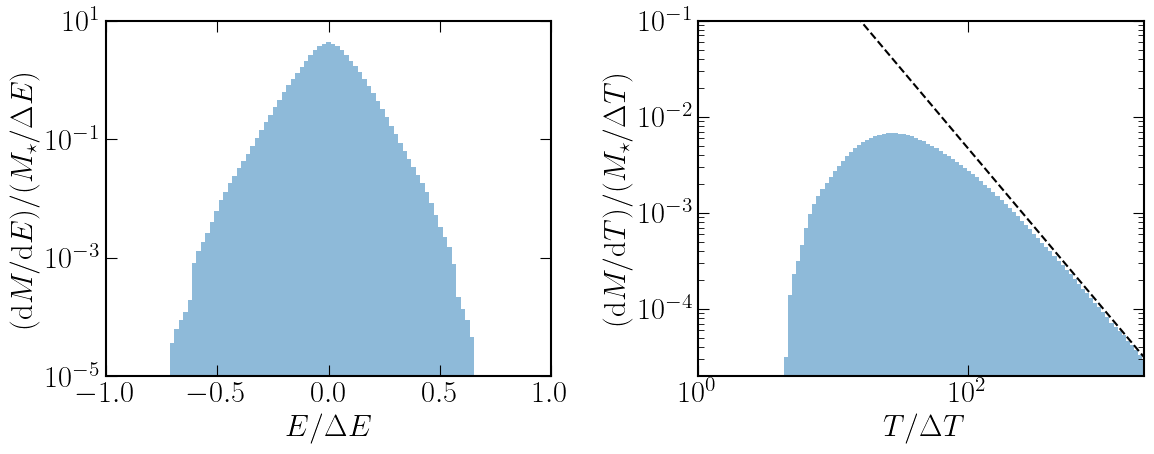

In [32]:
energy_plots(whole_star_sample_n)

it's not matching the newtonian case, what did I do wrong?

In [33]:
mass = 'MAMS5Msun'
Mbh = 1e6
Rp = 4.99
a = 0.5
n = 1000

In [34]:
calc = TDECalculator(mass, 'rel', Mbh, Rp, a, n)
calc_n = TDECalculator(mass, 'nwtn', Mbh, Rp, 0.0, n)
calc_s = TDECalculator(mass, 'rel', Mbh, Rp, 0.0, n)
calc2 = TDECalculator(mass, 'rel', Mbh, Rp, -a, n)

In [35]:
whole_star_sample1 = calc.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample2 = calc2.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample_s = calc_s.rel_whole_star_sample(N_Omega=300**2)
whole_star_sample_n = calc_n.whole_star_sample(N_Omega=300**2)

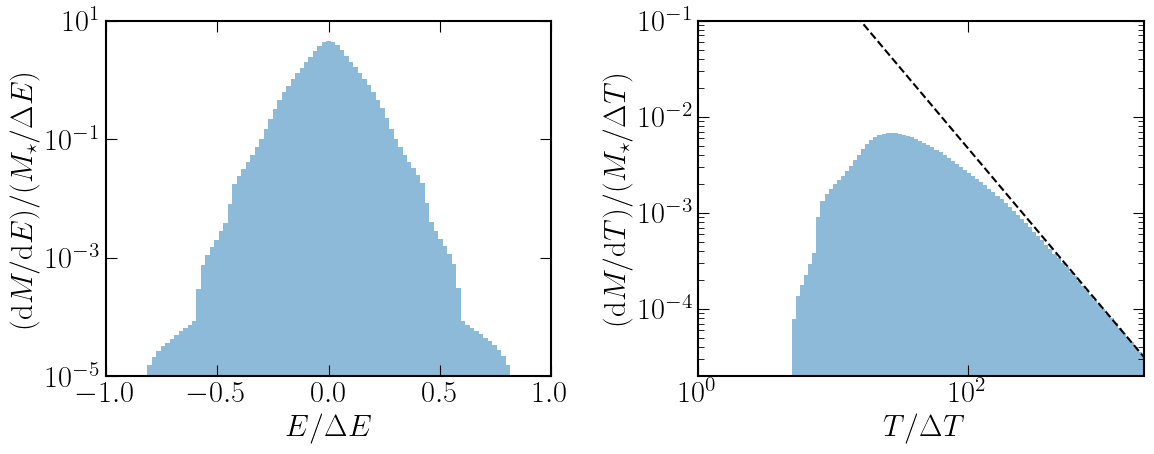

In [36]:
energy_plots(whole_star_sample1)

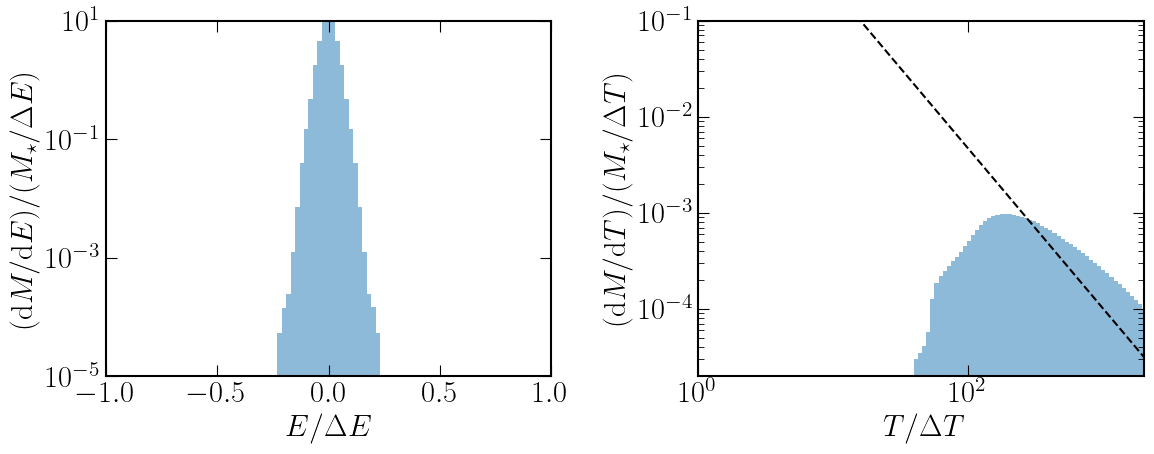

In [37]:
energy_plots(whole_star_sample2)

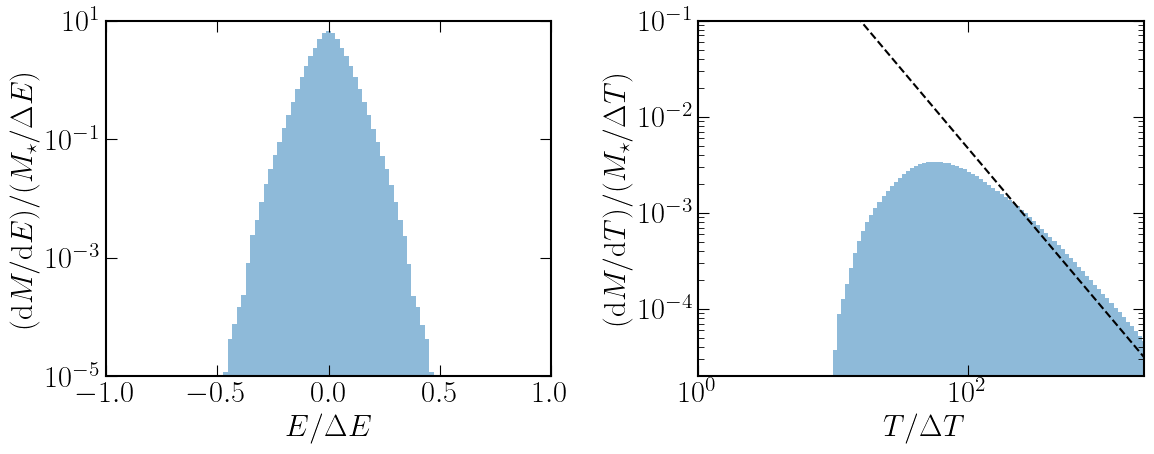

In [38]:
energy_plots(whole_star_sample_s)

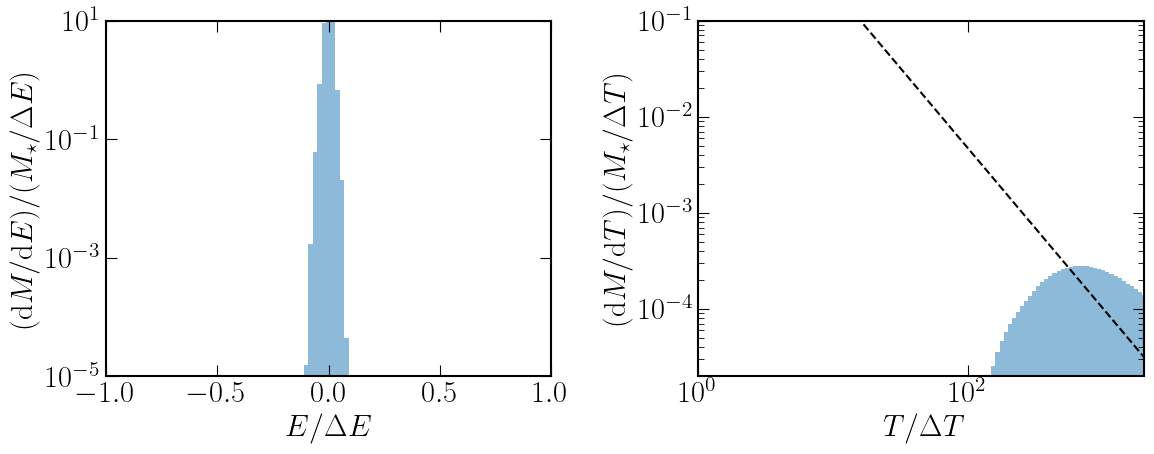

In [39]:
energy_plots(whole_star_sample_n)